In [21]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import keras
from keras.layers import Dense, Dropout
from keras.models import Sequential
from sklearn.metrics import confusion_matrix
import seaborn as sns

np.random.seed(0)

Data

In [15]:
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [16]:
print(X_train.shape , y_train.shape)
print(X_test.shape , y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


Vizualize Examples

IndexError: boolean index did not match indexed array along axis 1; size of axis is 784 but size of corresponding boolean axis is 10

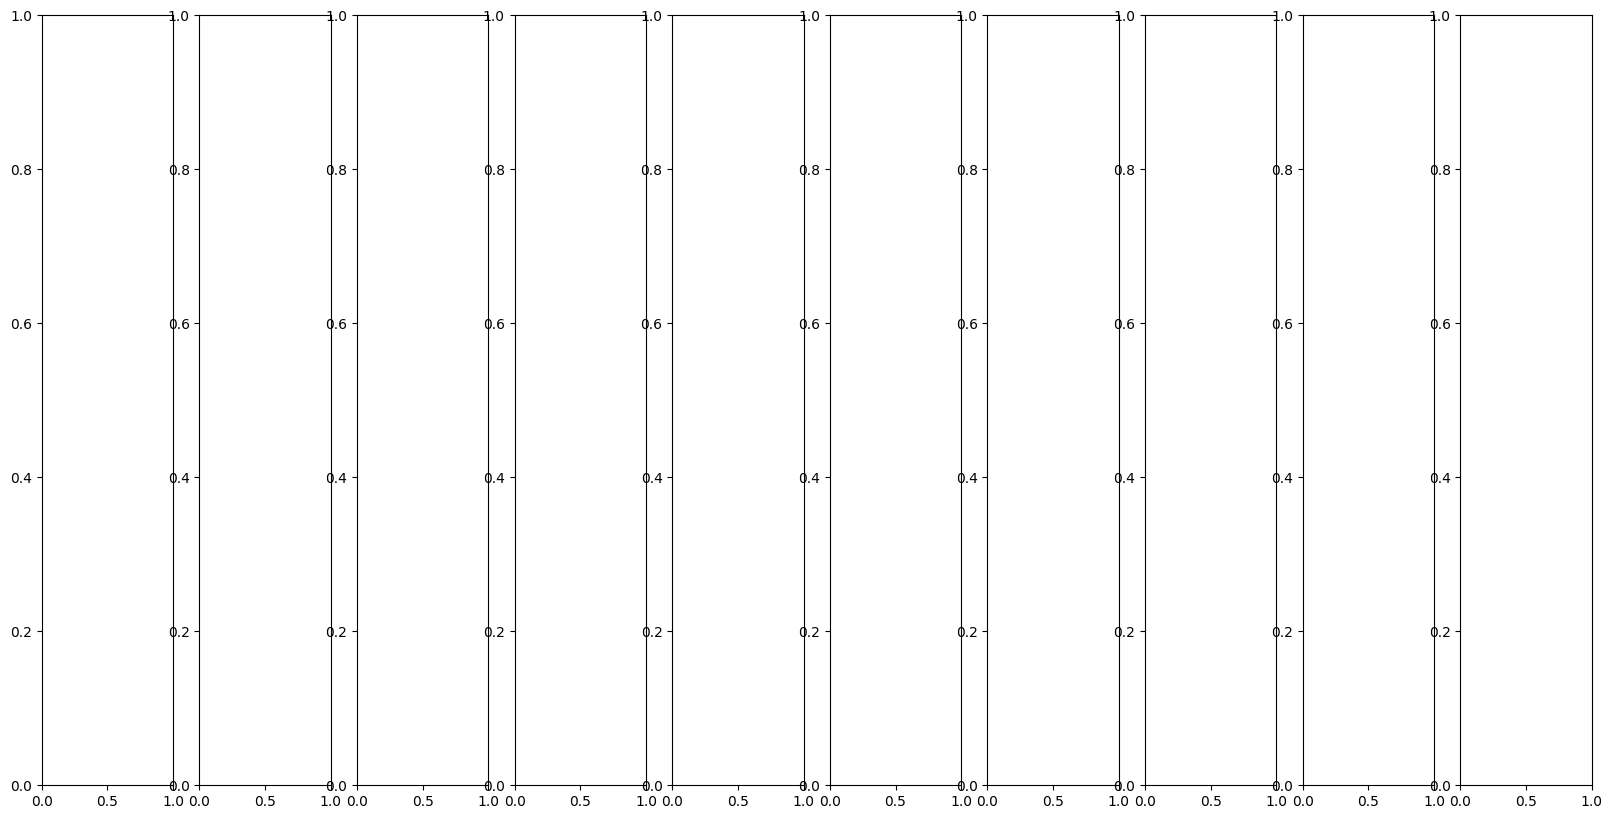

In [ ]:
num_classes = 10 
f, ax = plt.subplots(1,num_classes, figsize=(20,10))

for i in range(num_classes):
    sample = X_train[y_train == i][0]
    ax[i].imshow(sample, cmap='gray')
    ax[i].set_title('Label: {}'.format(i), fontdict={'fontsize': 20})

In [ ]:
for i in range(10):
    print(y_train[i])

5
0
4
1
9
2
1
3
1
4


In [ ]:
y_train = keras.utils.to_categorical(y_train, num_classes) #this creates the vectors for the labels. For example, if the label is 3, it will create a vector of length 10 with all zeros except for the 4th position which will be 1.
y_test = keras.utils.to_categorical(y_test, num_classes)

In [ ]:
for i in range(10):
    print(y_train[i])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


Prepare Data 

In [25]:
#Normalize data

X_train = X_train / 255
X_test = X_test / 255



In [27]:
#Reshape data 
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

In [29]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
print(X_train.shape)

(60000, 784)


Create Model - Fully Connected Neural Network

In [31]:
model = Sequential()

model.add(Dense(units=128, input_shape=(784,), activation='relu'))
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(units=num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

/Users/damiresflores/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
batch_size = 128
epochs = 10
model.fit(x=X_train, y=y_train, batch_size=batch_size, epochs=epochs)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8135 - loss: 0.6362
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8135 - loss: 0.6362
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9539 - loss: 0.1561
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9539 - loss: 0.1561
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9701 - loss: 0.1028
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9701 - loss: 0.1028
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9762 - loss: 0.0772
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9762 - loss: 0.0772
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9826 - loss: 0.0584
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9826 - loss: 0.0584
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9834 - loss: 0.0518
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - 

Evaluate

In [33]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test loss: {}, Test Accuracy : {}'.format(test_loss, test_acc))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 439us/step - accuracy: 0.9754 - loss: 0.0843
Test loss: 0.07170207798480988, Test Accuracy : 0.9800999760627747


In [35]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(y_pred_classes)
print(y_pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 306us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 306us/step
[7 2 1 ... 4 5 6]
[[3.3731409e-10 6.2609109e-07 5.4656493e-06 ... 9.9976599e-01
  1.3133829e-08 2.3724810e-07]
 [6.2260774e-10 2.9730332e-05 9.9997038e-01 ... 3.8298970e-10
  4.7787845e-09 2.5797151e-14]
 [7.9667181e-08 9.9956834e-01 4.8709881e-06 ... 6.9290778e-05
  1.9534086e-04 2.7448672e-07]
 ...
 [1.2377596e-14 1.9886930e-10 1.1010537e-15 ... 2.8444094e-10
  6.1986485e-11 9.5645163e-08]
 [1.6925726e-11 4.2784200e-14 1.0073983e-14 ... 2.4428357e-13
  3.2084722e-06 2.6336600e-12]
 [1.6739259e-10 2.2480431e-12 1.1123581e-10 ... 8.2727220e-17
  1.5133106e-10 3.2088759e-14]]
[7 2 1 ... 4 5 6]
[[3.3731409e-10 6.2609109e-07 5.4656493e-06 ... 9.9976599e-01
  1.3133829e-08 2.3724810e-07]
 [6.2260774e-10 2.9730332e-05 9.9997038e-01 ... 3.8298970e-10
  4.7787845e-09 2.5797151e-14]
 [7.9667181e-08 9.9956834e-01 4.8709881e-06 ... 6.9290778e-05
  1.9534086e-04 2.7448672e-07]
 ...
 [1.2377596e-14 1.9886930e-10 

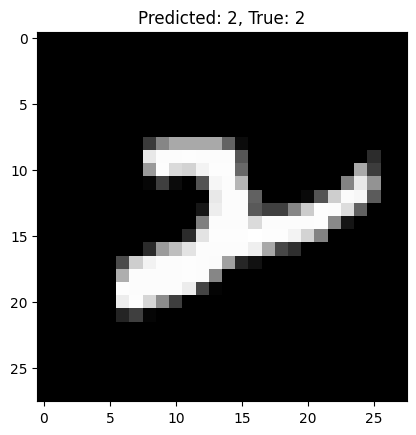

In [44]:
#Single example
random_idx = np.random.choice(len(X_test))
x_sample = X_test[random_idx]
y_true = np.argmax(y_test, axis=1)
y_sample_true = y_true[random_idx]
y_sample_pred_class = y_pred_classes[random_idx]

plt.title("Predicted: {}, True: {}".format(y_sample_pred_class, y_sample_true))
plt.imshow(x_sample.reshape(28,28), cmap='gray')


Confusion matrix

Text(0.5, 1.0, 'Confusion Matrix')

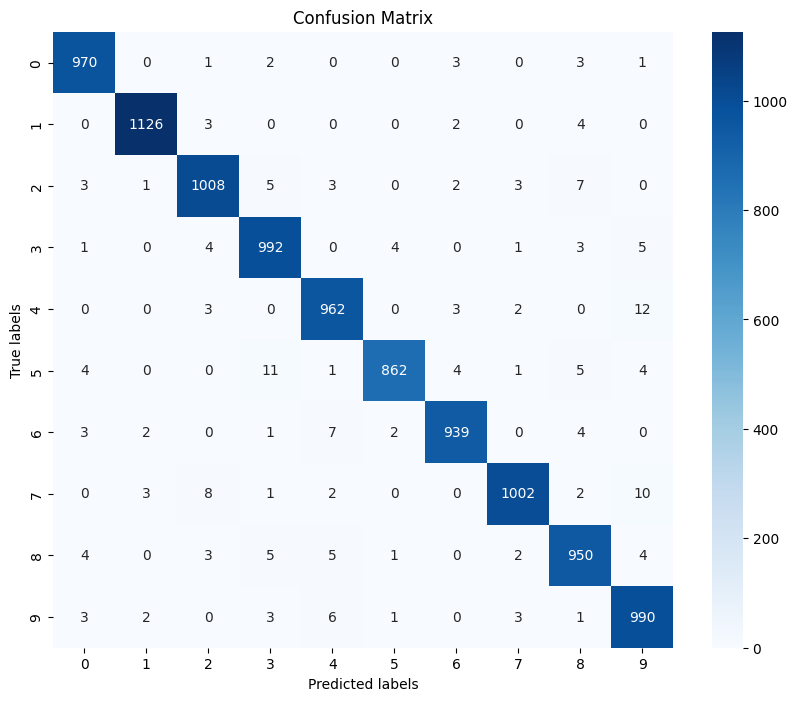

In [48]:
confusion_mtx = confusion_matrix(y_true, y_pred_classes)

fig, ax = plt.subplots(figsize=(10,8))
ax = sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues')
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')

Investigate misclassified examples


In [50]:
errors = (y_pred_classes - y_true != 0)
y_pred_classes_errors = y_pred_classes[errors]
y_pred_errors = y_pred[errors]
y_true_errors = y_true[errors]
X_test_errors = X_test[errors]



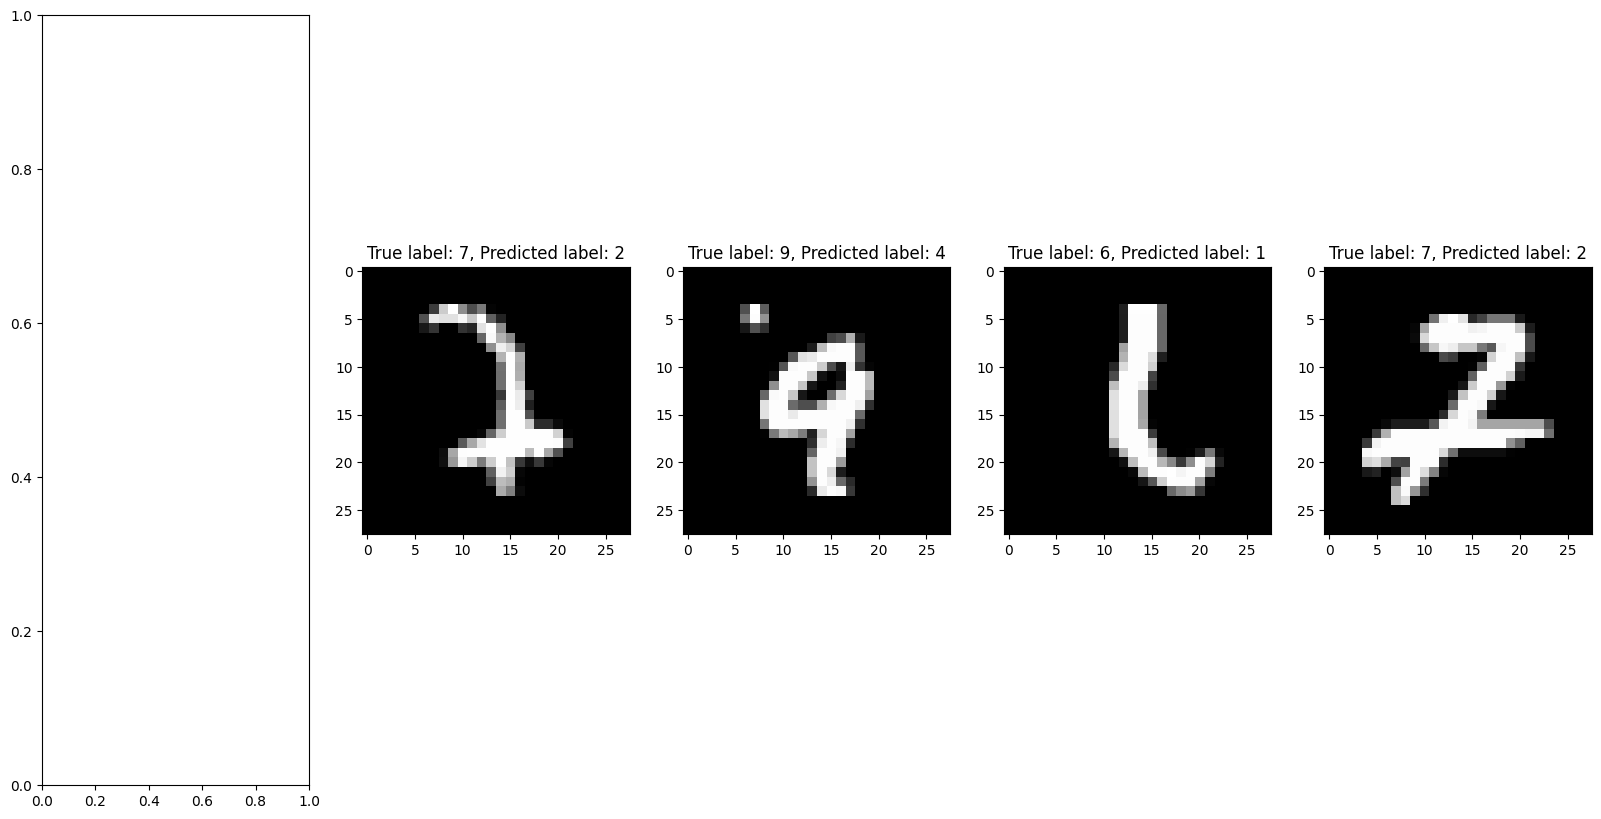

In [56]:
y_pred_errors_probability = np.max(y_pred[errors], axis=1)
true_probability = np.diagonal(np.take(y_pred_errors, y_true_errors, axis=1))
diff_errors_pred_true = y_pred_errors_probability - true_probability

#get list of indices of sorted differences
sorted_idx_diff_errors = np.argsort(diff_errors_pred_true)
top_idx_diff_errors = sorted_idx_diff_errors[-5:]

#show errors
num = len(top_idx_diff_errors)
f, ax = plt.subplots(1,num, figsize=(20,10))

for i in range(1,num):
    idx = top_idx_diff_errors[i]
    sample = X_test_errors[idx].reshape(28,28)
    y_t = y_true_errors[idx]
    y_p = y_pred_classes_errors[idx]
    ax[i].imshow(sample, cmap='gray')
    ax[i].set_title('True label: {}, Predicted label: {}'.format(y_t, y_p))